In [1]:
!pip -q install "torchmetrics[image]" torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.7 MB/s eta 0:00:00


In [2]:
import os
import time
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from torchvision.utils import make_grid, save_image

from torchmetrics.image.fid import FrechetInceptionDistance

from google.colab import drive


SEED = 42


def set_seed(seed=SEED):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)


set_seed()


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


if device.type != "cuda":

    raise RuntimeError(
        "GPU is not active. Enable GPU in Colab."
    )


torch.backends.cudnn.benchmark = True


print("Device:", device)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

Device: cuda
GPU: Tesla T4


In [3]:
drive.mount(
    "/content/drive"
)


OUTPUT_DIR = (
    "/content/drive/MyDrive/dl_pset6_results"
)


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


T = 1000

BATCH_SIZE = 128

BASE_CHANNELS = 32

TIME_DIM = 128

UNCOND_EPOCHS = 8

COND_EPOCHS = 8

NUM_CLASSES = 10

FID_SAMPLES = 64

GUIDANCE_SCALE = 2.0


print(
    "Output folder:",
    OUTPUT_DIR
)

Mounted at /content/drive
Output folder: /content/drive/MyDrive/dl_pset6_results


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


train_dataset = (
    torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )
)


test_dataset = (
    torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

100%|██████████| 170M/170M [19:54<00:00, 143kB/s]


Training samples: 50000
Test samples: 10000


In [5]:
betas = torch.linspace(
    1e-4,
    0.02,
    T,
    device=device
)


alphas = (
    1.0 - betas
)


alpha_bars = torch.cumprod(
    alphas,
    dim=0
)


alpha_bars_previous = torch.cat([
    torch.ones(
        1,
        device=device
    ),
    alpha_bars[:-1]
])


posterior_variance = (
    betas
    *
    (
        1.0
        - alpha_bars_previous
    )
    /
    (
        1.0
        - alpha_bars
    )
)


def extract(
    values,
    t,
    shape
):

    result = values.gather(
        0,
        t
    )

    return result.view(
        t.size(0),
        *(
            [1]
            * (
                len(shape)
                - 1
            )
        )
    )


def q_sample(
    x_start,
    t,
    noise=None
):

    if noise is None:

        noise = torch.randn_like(
            x_start
        )

    sqrt_alpha_bar = torch.sqrt(
        extract(
            alpha_bars,
            t,
            x_start.shape
        )
    )

    sqrt_one_minus = torch.sqrt(
        1.0
        -
        extract(
            alpha_bars,
            t,
            x_start.shape
        )
    )

    return (
        sqrt_alpha_bar
        * x_start
        +
        sqrt_one_minus
        * noise
    )

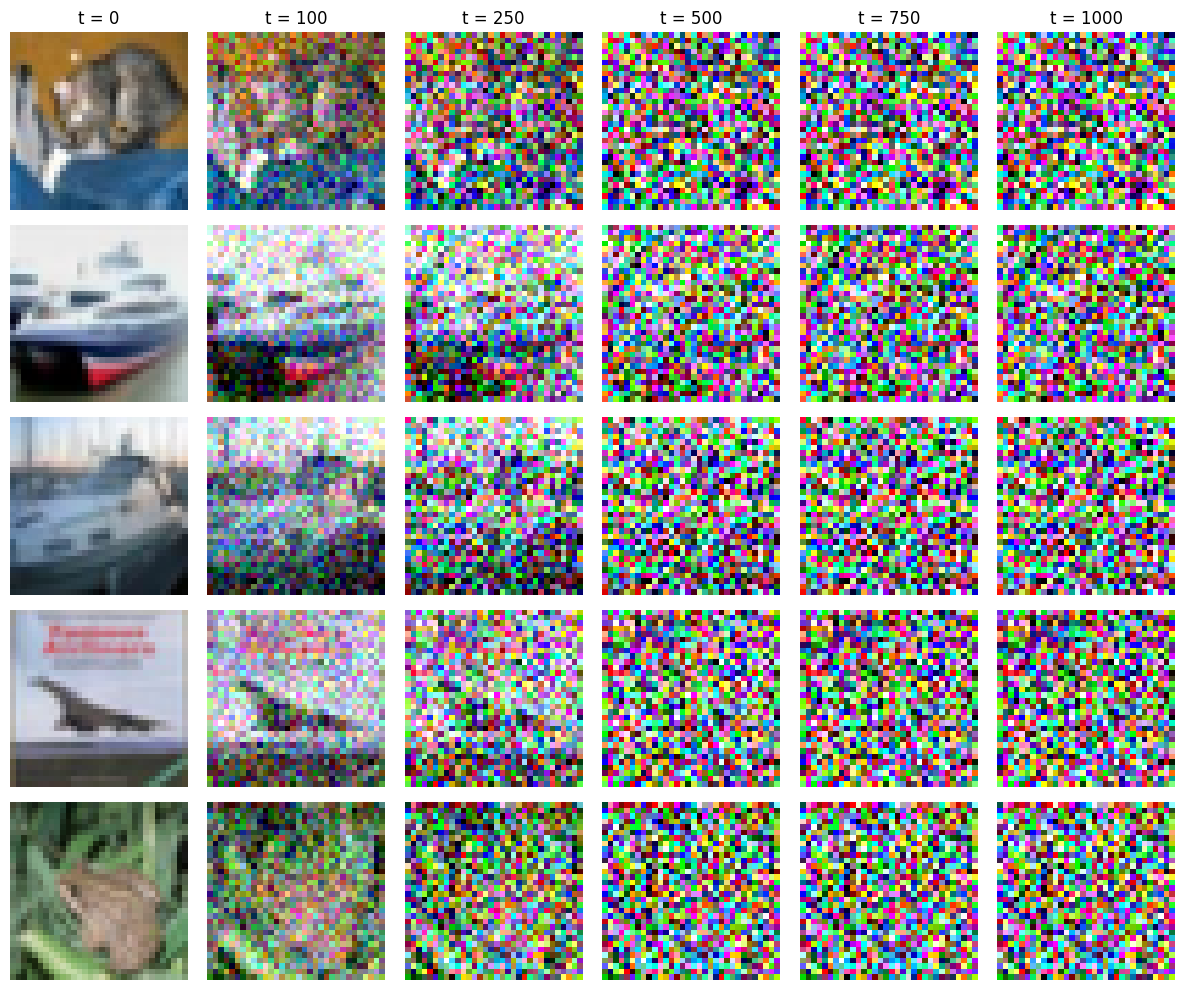

In [6]:
forward_images, _ = next(
    iter(test_loader)
)


forward_images = (
    forward_images[:5]
    .to(device)
)


fixed_forward_noise = (
    torch.randn_like(
        forward_images
    )
)


forward_steps = [
    0,
    100,
    250,
    500,
    750,
    1000
]


fig, axes = plt.subplots(
    5,
    len(forward_steps),
    figsize=(12, 10)
)


for column, step in enumerate(
    forward_steps
):

    if step == 0:

        noisy = forward_images

    else:

        t = torch.full(
            (5,),
            min(
                step - 1,
                T - 1
            ),
            device=device,
            dtype=torch.long
        )

        noisy = q_sample(
            forward_images,
            t,
            fixed_forward_noise
        )

    noisy = (
        (noisy + 1)
        / 2
    ).clamp(
        0,
        1
    )

    for row in range(5):

        axes[
            row,
            column
        ].imshow(
            noisy[row]
            .permute(
                1,
                2,
                0
            )
            .cpu()
        )

        axes[
            row,
            column
        ].axis(
            "off"
        )

        if row == 0:

            axes[
                row,
                column
            ].set_title(
                f"t = {step}"
            )


plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "forward_diffusion.png"
    )
)


plt.show()

In [7]:
class SinusoidalTimeEmbedding(
    nn.Module
):

    def __init__(
        self,
        dim
    ):

        super().__init__()

        self.dim = dim


    def forward(
        self,
        t
    ):

        half = (
            self.dim // 2
        )

        frequencies = torch.exp(
            -math.log(10000)
            *
            torch.arange(
                half,
                device=t.device
            )
            /
            (
                half - 1
            )
        )

        angles = (
            t.float()[:, None]
            *
            frequencies[None, :]
        )

        return torch.cat(
            [
                angles.sin(),
                angles.cos()
            ],
            dim=1
        )


class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim,
        dropout=0.1
    ):

        super().__init__()

        self.norm1 = nn.GroupNorm(
            8,
            in_channels
        )

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            padding=1
        )

        self.time_projection = (
            nn.Linear(
                time_dim,
                out_channels
            )
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding=1
        )

        if (
            in_channels
            != out_channels
        ):

            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                1
            )

        else:

            self.skip = nn.Identity()


    def forward(
        self,
        x,
        time_embedding
    ):

        h = self.conv1(
            F.silu(
                self.norm1(x)
            )
        )

        h = (
            h
            +
            self.time_projection(
                time_embedding
            )[:, :, None, None]
        )

        h = self.conv2(
            self.dropout(
                F.silu(
                    self.norm2(h)
                )
            )
        )

        return (
            h
            +
            self.skip(x)
        )

In [8]:
class SmallUNet(nn.Module):

    def __init__(
        self,
        base=32,
        time_dim=128,
        num_classes=None
    ):

        super().__init__()

        self.num_classes = (
            num_classes
        )

        self.null_label = (
            num_classes
            if num_classes
            is not None
            else None
        )

        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(
                time_dim
            ),
            nn.Linear(
                time_dim,
                time_dim
            ),
            nn.SiLU(),
            nn.Linear(
                time_dim,
                time_dim
            )
        )

        if num_classes is not None:

            self.label_embedding = (
                nn.Embedding(
                    num_classes + 1,
                    time_dim
                )
            )

        else:

            self.label_embedding = None

        self.input = nn.Conv2d(
            3,
            base,
            3,
            padding=1
        )

        self.down1 = ResBlock(
            base,
            base,
            time_dim
        )

        self.downsample1 = nn.Conv2d(
            base,
            base * 2,
            4,
            2,
            1
        )

        self.down2 = ResBlock(
            base * 2,
            base * 2,
            time_dim
        )

        self.downsample2 = nn.Conv2d(
            base * 2,
            base * 4,
            4,
            2,
            1
        )

        self.middle1 = ResBlock(
            base * 4,
            base * 4,
            time_dim
        )

        self.middle2 = ResBlock(
            base * 4,
            base * 4,
            time_dim
        )

        self.upsample1 = (
            nn.ConvTranspose2d(
                base * 4,
                base * 2,
                4,
                2,
                1
            )
        )

        self.up1 = ResBlock(
            base * 4,
            base * 2,
            time_dim
        )

        self.upsample2 = (
            nn.ConvTranspose2d(
                base * 2,
                base,
                4,
                2,
                1
            )
        )

        self.up2 = ResBlock(
            base * 2,
            base,
            time_dim
        )

        self.output_norm = (
            nn.GroupNorm(
                8,
                base
            )
        )

        self.output = nn.Conv2d(
            base,
            3,
            3,
            padding=1
        )


    def forward(
        self,
        x,
        t,
        labels=None
    ):

        time_embedding = (
            self.time_mlp(t)
        )

        if (
            self.label_embedding
            is not None
        ):

            if labels is None:

                labels = torch.full(
                    (
                        x.size(0),
                    ),
                    self.null_label,
                    device=x.device,
                    dtype=torch.long
                )

            time_embedding = (
                time_embedding
                +
                self.label_embedding(
                    labels
                )
            )

        x = self.input(x)

        h1 = self.down1(
            x,
            time_embedding
        )

        x = self.downsample1(
            h1
        )

        h2 = self.down2(
            x,
            time_embedding
        )

        x = self.downsample2(
            h2
        )

        x = self.middle1(
            x,
            time_embedding
        )

        x = self.middle2(
            x,
            time_embedding
        )

        x = self.upsample1(
            x
        )

        x = torch.cat(
            [
                x,
                h2
            ],
            dim=1
        )

        x = self.up1(
            x,
            time_embedding
        )

        x = self.upsample2(
            x
        )

        x = torch.cat(
            [
                x,
                h1
            ],
            dim=1
        )

        x = self.up2(
            x,
            time_embedding
        )

        x = self.output(
            F.silu(
                self.output_norm(
                    x
                )
            )
        )

        return x


def count_parameters(
    model
):

    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )

In [9]:
def train_diffusion(
    model,
    loader,
    epochs,
    conditional=False,
    label_drop=0.1
):

    model = model.to(
        device
    )

    optimizer = (
        torch.optim.AdamW(
            model.parameters(),
            lr=2e-4,
            weight_decay=1e-4
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda"
    )

    history = []

    total_start = (
        time.perf_counter()
    )

    for epoch in range(
        1,
        epochs + 1
    ):

        model.train()

        losses = []

        epoch_start = (
            time.perf_counter()
        )

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            batch_size = (
                images.size(0)
            )

            t = torch.randint(
                0,
                T,
                (
                    batch_size,
                ),
                device=device
            )

            noise = torch.randn_like(
                images
            )

            noisy_images = q_sample(
                images,
                t,
                noise
            )

            train_labels = None

            if conditional:

                train_labels = (
                    labels.clone()
                )

                drop_mask = (
                    torch.rand(
                        batch_size,
                        device=device
                    )
                    < label_drop
                )

                train_labels[
                    drop_mask
                ] = NUM_CLASSES

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda"
            ):

                predicted_noise = model(
                    noisy_images,
                    t,
                    train_labels
                )

                loss = F.mse_loss(
                    predicted_noise,
                    noise
                )

            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

            losses.append(
                loss.item()
            )

        epoch_time = (
            time.perf_counter()
            - epoch_start
        )

        mean_loss = np.mean(
            losses
        )

        history.append({
            "Epoch": epoch,
            "Loss": mean_loss,
            "Epoch Time":
                epoch_time
        })

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Loss {mean_loss:.4f} | "
            f"time {epoch_time:.1f}s"
        )

    total_time = (
        time.perf_counter()
        - total_start
    )

    return (
        model,
        pd.DataFrame(
            history
        ),
        total_time
    )

In [10]:
set_seed()


unconditional_model = SmallUNet(
    base=BASE_CHANNELS,
    time_dim=TIME_DIM
).to(device)


print(
    "Unconditional parameters:",
    count_parameters(
        unconditional_model
    )
)


(
    unconditional_model,
    unconditional_history,
    unconditional_training_time
) = train_diffusion(
    unconditional_model,
    train_loader,
    UNCOND_EPOCHS,
    conditional=False
)


torch.save(
    unconditional_model.state_dict(),
    os.path.join(
        OUTPUT_DIR,
        "unconditional_ddpm.pt"
    )
)


unconditional_history.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "unconditional_history.csv"
    ),
    index=False
)


print(
    "Training time:",
    round(
        unconditional_training_time
        / 60,
        2
    ),
    "minutes"
)

Unconditional parameters: 1254051
Epoch 01/8 | Loss 0.1686 | time 35.9s
Epoch 02/8 | Loss 0.0653 | time 20.5s
Epoch 03/8 | Loss 0.0557 | time 19.0s
Epoch 04/8 | Loss 0.0488 | time 18.9s
Epoch 05/8 | Loss 0.0461 | time 21.1s
Epoch 06/8 | Loss 0.0442 | time 20.3s
Epoch 07/8 | Loss 0.0427 | time 21.2s
Epoch 08/8 | Loss 0.0416 | time 19.5s
Training time: 2.94 minutes


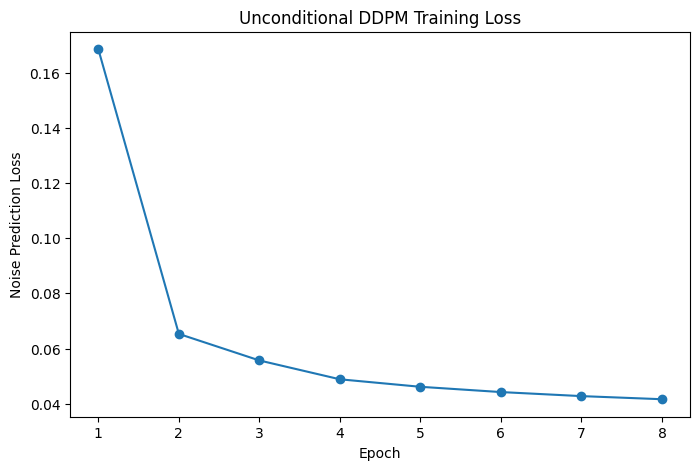

In [11]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    unconditional_history[
        "Epoch"
    ],
    unconditional_history[
        "Loss"
    ],
    marker="o"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Noise Prediction Loss"
)

plt.title(
    "Unconditional DDPM Training Loss"
)

plt.show()

In [12]:
def reverse_step(
    x,
    t,
    predicted_noise
):

    beta_t = extract(
        betas,
        t,
        x.shape
    )

    alpha_t = extract(
        alphas,
        t,
        x.shape
    )

    alpha_bar_t = extract(
        alpha_bars,
        t,
        x.shape
    )

    variance_t = extract(
        posterior_variance,
        t,
        x.shape
    )

    mean = (
        x
        -
        (
            beta_t
            /
            torch.sqrt(
                1.0
                - alpha_bar_t
            )
        )
        *
        predicted_noise
    )

    mean = (
        mean
        /
        torch.sqrt(
            alpha_t
        )
    )

    noise = torch.randn_like(
        x
    )

    nonzero = (
        t != 0
    ).float().view(
        -1,
        1,
        1,
        1
    )

    return (
        mean
        +
        nonzero
        *
        torch.sqrt(
            variance_t
        )
        *
        noise
    )


@torch.no_grad()
def sample_ddpm(
    model,
    n_samples,
    labels=None,
    guidance_scale=None,
    capture=False
):

    model.eval()

    if labels is not None:

        labels = labels.to(
            device
        )

    x = torch.randn(
        n_samples,
        3,
        32,
        32,
        device=device
    )

    snapshots = {}

    if capture:

        snapshots[1000] = (
            x.detach()
            .cpu()
            .clone()
        )

    capture_map = {
        749: 750,
        499: 500,
        249: 250,
        99: 100
    }

    start = time.perf_counter()

    for step in range(
        T - 1,
        -1,
        -1
    ):

        if (
            capture
            and step
            in capture_map
        ):

            snapshots[
                capture_map[
                    step
                ]
            ] = (
                x.detach()
                .cpu()
                .clone()
            )

        t = torch.full(
            (
                n_samples,
            ),
            step,
            device=device,
            dtype=torch.long
        )

        if (
            labels is not None
            and guidance_scale
            is not None
        ):

            null_labels = (
                torch.full_like(
                    labels,
                    model.null_label
                )
            )

            unconditional_noise = (
                model(
                    x,
                    t,
                    null_labels
                )
            )

            conditional_noise = (
                model(
                    x,
                    t,
                    labels
                )
            )

            predicted_noise = (
                unconditional_noise
                +
                guidance_scale
                *
                (
                    conditional_noise
                    -
                    unconditional_noise
                )
            )

        else:

            predicted_noise = model(
                x,
                t,
                labels
            )

        x = reverse_step(
            x,
            t,
            predicted_noise
        )

    sampling_time = (
        time.perf_counter()
        - start
    )

    x = x.clamp(
        -1,
        1
    )

    if capture:

        snapshots[0] = (
            x.detach()
            .cpu()
            .clone()
        )

    return (
        x.cpu(),
        snapshots,
        sampling_time
    )


def to_image_range(
    images
):

    return (
        (images + 1)
        / 2
    ).clamp(
        0,
        1
    )

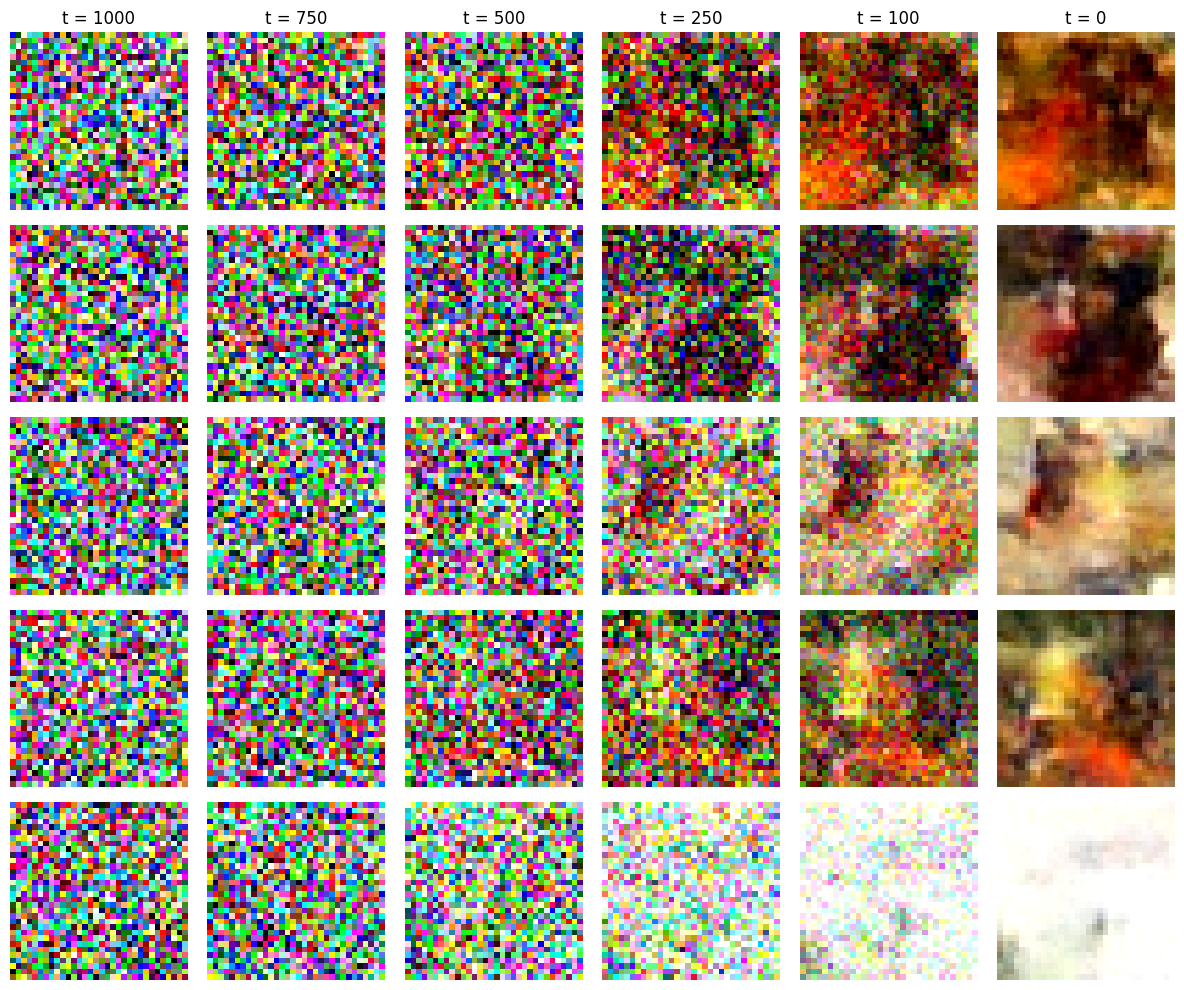

In [13]:
(
    reverse_final,
    reverse_snapshots,
    reverse_time
) = sample_ddpm(
    unconditional_model,
    n_samples=5,
    capture=True
)


reverse_steps = [
    1000,
    750,
    500,
    250,
    100,
    0
]


fig, axes = plt.subplots(
    5,
    len(reverse_steps),
    figsize=(12, 10)
)


for column, step in enumerate(
    reverse_steps
):

    images = to_image_range(
        reverse_snapshots[
            step
        ]
    )

    for row in range(5):

        axes[
            row,
            column
        ].imshow(
            images[row]
            .permute(
                1,
                2,
                0
            )
        )

        axes[
            row,
            column
        ].axis(
            "off"
        )

        if row == 0:

            axes[
                row,
                column
            ].set_title(
                f"t = {step}"
            )


plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "reverse_denoising.png"
    )
)


plt.show()

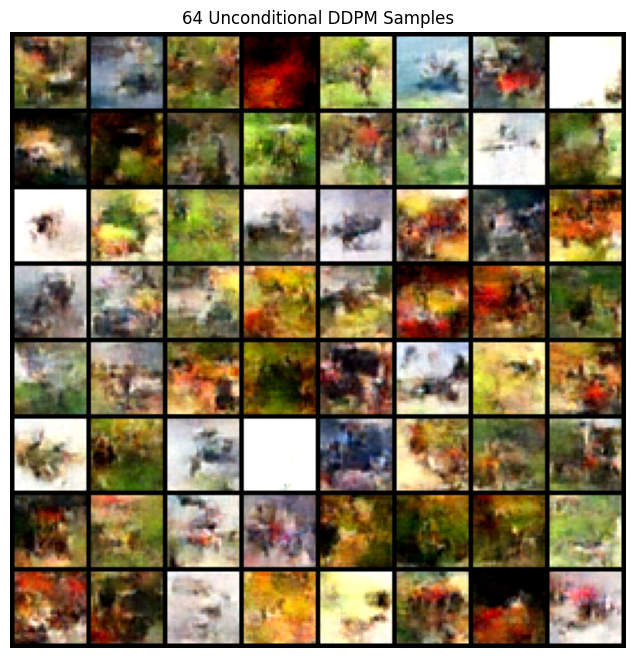

Sampling time: 9.2 seconds


In [14]:
(
    unconditional_samples,
    _,
    unconditional_sampling_time
) = sample_ddpm(
    unconditional_model,
    n_samples=64
)


grid = make_grid(
    to_image_range(
        unconditional_samples
    ),
    nrow=8
)


plt.figure(
    figsize=(8, 8)
)


plt.imshow(
    grid.permute(
        1,
        2,
        0
    )
)


plt.axis(
    "off"
)

plt.title(
    "64 Unconditional DDPM Samples"
)

plt.show()


save_image(
    to_image_range(
        unconditional_samples
    ),
    os.path.join(
        OUTPUT_DIR,
        "unconditional_samples.png"
    ),
    nrow=8
)


print(
    "Sampling time:",
    round(
        unconditional_sampling_time,
        2
    ),
    "seconds"
)

In [15]:
def compute_fid(
    real_images,
    fake_images
):

    metric = (
        FrechetInceptionDistance(
            feature=2048,
            normalize=True
        )
        .to(device)
    )

    metric.update(
        to_image_range(
            real_images
        ).to(device),
        real=True
    )

    metric.update(
        to_image_range(
            fake_images
        ).to(device),
        real=False
    )

    score = (
        metric.compute()
        .item()
    )

    del metric

    torch.cuda.empty_cache()

    return score


real_fid_images, _ = next(
    iter(test_loader)
)


real_fid_images = (
    real_fid_images[
        :FID_SAMPLES
    ]
)


unconditional_fid = compute_fid(
    real_fid_images,
    unconditional_samples
)


print(
    "Unconditional DDPM FID:",
    unconditional_fid
)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 33.3MB/s]


Unconditional DDPM FID: 292.8779296875


In [16]:
set_seed()


conditional_model = SmallUNet(
    base=BASE_CHANNELS,
    time_dim=TIME_DIM,
    num_classes=NUM_CLASSES
).to(device)


print(
    "Conditional parameters:",
    count_parameters(
        conditional_model
    )
)

Conditional parameters: 1255459


In [17]:
(
    conditional_model,
    conditional_history,
    conditional_training_time
) = train_diffusion(
    conditional_model,
    train_loader,
    COND_EPOCHS,
    conditional=True,
    label_drop=0.1
)


torch.save(
    conditional_model.state_dict(),
    os.path.join(
        OUTPUT_DIR,
        "conditional_ddpm.pt"
    )
)


conditional_history.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "conditional_history.csv"
    ),
    index=False
)


print(
    "Conditional training time:",
    round(
        conditional_training_time
        / 60,
        2
    ),
    "minutes"
)

Epoch 01/8 | Loss 0.1956 | time 22.6s
Epoch 02/8 | Loss 0.0661 | time 20.4s
Epoch 03/8 | Loss 0.0529 | time 21.4s
Epoch 04/8 | Loss 0.0486 | time 19.8s
Epoch 05/8 | Loss 0.0457 | time 20.0s
Epoch 06/8 | Loss 0.0435 | time 21.4s
Epoch 07/8 | Loss 0.0420 | time 20.1s
Epoch 08/8 | Loss 0.0405 | time 21.5s
Conditional training time: 2.79 minutes


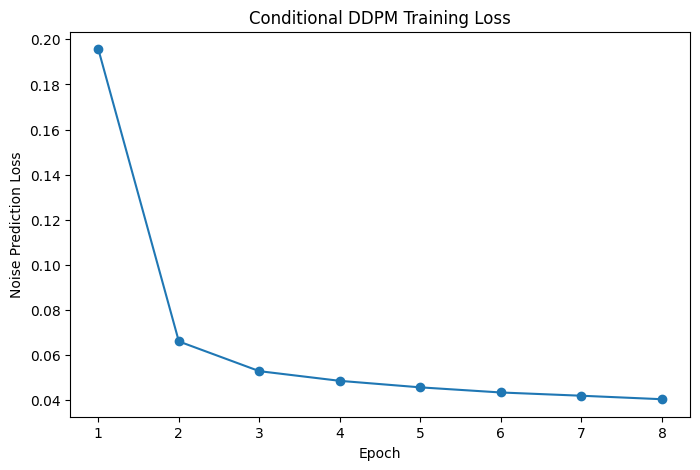

In [18]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    conditional_history[
        "Epoch"
    ],
    conditional_history[
        "Loss"
    ],
    marker="o"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Noise Prediction Loss"
)

plt.title(
    "Conditional DDPM Training Loss"
)

plt.show()

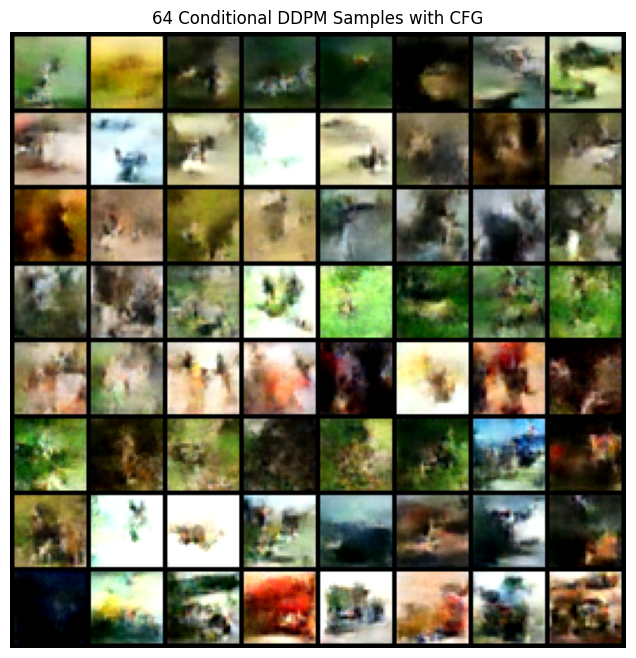

Class labels:
[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9]
Sampling time: 18.09 seconds


In [19]:
conditional_labels = (
    torch.arange(
        64,
        device=device
    )
    *
    NUM_CLASSES
    //
    64
).long()


(
    conditional_samples,
    _,
    conditional_sampling_time
) = sample_ddpm(
    conditional_model,
    n_samples=64,
    labels=conditional_labels,
    guidance_scale=GUIDANCE_SCALE
)


grid = make_grid(
    to_image_range(
        conditional_samples
    ),
    nrow=8
)


plt.figure(
    figsize=(8, 8)
)


plt.imshow(
    grid.permute(
        1,
        2,
        0
    )
)


plt.axis(
    "off"
)

plt.title(
    "64 Conditional DDPM Samples with CFG"
)

plt.show()


save_image(
    to_image_range(
        conditional_samples
    ),
    os.path.join(
        OUTPUT_DIR,
        "conditional_samples.png"
    ),
    nrow=8
)


print(
    "Class labels:"
)


print(
    conditional_labels
    .cpu()
    .tolist()
)


print(
    "Sampling time:",
    round(
        conditional_sampling_time,
        2
    ),
    "seconds"
)

In [20]:
conditional_fid = compute_fid(
    real_fid_images,
    conditional_samples
)


quality_comparison = pd.DataFrame([
    {
        "Model":
            "Unconditional DDPM",
        "FID":
            unconditional_fid,
        "Samples":
            FID_SAMPLES
    },
    {
        "Model":
            "Conditional DDPM + CFG",
        "FID":
            conditional_fid,
        "Samples":
            FID_SAMPLES
    }
])


quality_comparison

,Model,FID,Samples
0,Unconditional DDPM,292.877930,64
1,Conditional DDPM + CFG,263.604553,64


In [21]:
GAN_FID_PROBLEM4 = 68.649940


final_comparison = pd.DataFrame([
    {
        "Model":
            "Unconditional DDPM",
        "FID":
            unconditional_fid,
        "FID Samples":
            FID_SAMPLES,
        "Training Minutes":
            unconditional_training_time
            / 60,
        "Sampling Seconds":
            unconditional_sampling_time
    },
    {
        "Model":
            "Conditional DDPM + CFG",
        "FID":
            conditional_fid,
        "FID Samples":
            FID_SAMPLES,
        "Training Minutes":
            conditional_training_time
            / 60,
        "Sampling Seconds":
            conditional_sampling_time
    },
    {
        "Model":
            "DCGAN Problem 4",
        "FID":
            GAN_FID_PROBLEM4,
        "FID Samples":
            2000,
        "Training Minutes":
            21.68,
        "Sampling Seconds":
            np.nan
    }
])


final_comparison

,Model,FID,FID Samples,Training Minutes,Sampling Seconds
0,Unconditional DDPM,292.877930,64,2.938861,9.204343
1,Conditional DDPM + CFG,263.604553,64,2.785827,18.089305
2,DCGAN Problem 4,68.649940,2000,21.680000,NaN


In [22]:
quality_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "conditional_vs_unconditional.csv"
    ),
    index=False
)


final_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_comparison.csv"
    ),
    index=False
)


print(
    "Problem 6 completed."
)


print(
    "All important results saved in:"
)


print(
    OUTPUT_DIR
)

Problem 6 completed.
All important results saved in:
/content/drive/MyDrive/dl_pset6_results
